In [13]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pathlib import Path
import glob
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Added to path: {current_dir}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka\dynamic_trend_model


In [14]:
"""
Metrics Comparison Toolkit for Water Meter Anomaly Detection Models

This module provides utilities to load, analyze, and compare metrics
across multiple models in Jupyter notebooks with nice pandas table display.

Key Features:
- Load model results from CSV files
- Compute mean and standard deviation of metrics
- Display as formatted pandas DataFrame in Jupyter
- Filter by metric type (all vs non-zero only)

Purpose: Compare multiple anomaly detection models
"""


def load_model_results(csv_filepath: str, verbose: bool = True) -> pd.DataFrame:
    """
    Load and filter model results from CSV file.

    Parameters
    ----------
    csv_filepath : str
        Path to CSV file with model results
    verbose : bool
        Print loading status

    Returns
    -------
    pd.DataFrame
        Dataframe with only successful runs
    """
    try:
        df = pd.read_csv(csv_filepath)
        successful = df[df['status'] == 'success'].copy()

        if verbose and len(successful) > 0:
            print(f"✓ Loaded {len(successful)} successful runs")

        return successful
    except Exception as e:
        print(f"✗ Error loading {csv_filepath}: {e}")
        return pd.DataFrame()


def extract_metrics(df: pd.DataFrame, include_non_zero_only: bool = False) -> pd.DataFrame:
    """
    Extract metric columns from results dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe
    include_non_zero_only : bool
        If True, extract only _nz metrics

    Returns
    -------
    pd.DataFrame
        Dataframe with only metric columns
    """
    metric_cols = [col for col in df.columns if col.startswith('metric_')]

    if include_non_zero_only:
        # Include only non-zero and summary metrics
        metric_cols = [col for col in metric_cols if col.endswith('_nz') or 
                       col in ['metric_total_count', 'metric_non_zero_count', 
                              'metric_zero_count', 'metric_non_zero_percentage']]

    return df[metric_cols]


def compute_metrics_summary(csv_filepaths: Union[List[str], str], 
                            model_names: List[str] = None,
                            include_non_zero_only: bool = False,
                            only_converged: bool = False,
                            verbose: bool = True) -> pd.DataFrame:
    """
    Compute mean and std of metrics across samples for each model.

    Creates a summary table where:
    - Rows: Different metrics
    - Columns: Model names with Mean and Std subcolumns

    Parameters
    ----------
    csv_filepaths : Union[List[str], str]
        List of CSV file paths or glob pattern
    model_names : List[str], optional
        Names for each model. If None, uses filenames.
    include_non_zero_only : bool
        If True, only include non-zero metrics
    only_converged : bool
        If True, compute metrics only on rows where converged == True
    verbose : bool
        Print loading progress

    Returns
    -------
    pd.DataFrame
        Summary table with metrics as rows and models as columns
    """

    # Handle glob pattern
    if isinstance(csv_filepaths, str) and ('*' in csv_filepaths or '?' in csv_filepaths):
        csv_filepaths = sorted(glob.glob(csv_filepaths))
    elif isinstance(csv_filepaths, str):
        csv_filepaths = [csv_filepaths]

    if not csv_filepaths:
        raise ValueError("No CSV files found")

    # Set default model names
    if model_names is None:
        model_names = [Path(f).stem for f in csv_filepaths]

    if len(csv_filepaths) != len(model_names):
        raise ValueError(f"Mismatch: {len(csv_filepaths)} files vs {len(model_names)} names")

    # Load data
    model_data = {}
    all_metrics = set()
    successful_counts = {}

    if verbose:
        print(f"Loading {len(csv_filepaths)} model(s)...")
        print("-" * 80)

    for filepath, model_name in zip(csv_filepaths, model_names):
        df = load_model_results(filepath, verbose=verbose)

        # NEW: filter only converged problems (if requested and column exists)
        if only_converged and 'converged_train' in df.columns:
            df = df[(df['converged_train'] == True) & (df['converged_second'] == True)].copy()
            if verbose:
                print(f"  {model_name}: filtered to {len(df)} converged_train runs")

        if len(df) > 0:
            metrics_df = extract_metrics(df, include_non_zero_only)
            model_data[model_name] = metrics_df
            successful_counts[model_name] = len(metrics_df)
            all_metrics.update(metrics_df.columns)
        else:
            model_data[model_name] = None
            successful_counts[model_name] = 0

    if verbose:
        print("-" * 80)

    # Build summary table
    all_metrics = sorted(all_metrics)
    summary_rows = []

    for metric in all_metrics:
        row_data = {'Metric': metric}

        for model_name in model_names:
            if model_data[model_name] is None:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
            else:
                metrics_df = model_data[model_name]
                if metric in metrics_df.columns:
                    row_data[f"{model_name}_Mean"] = metrics_df[metric].mean()
                    row_data[f"{model_name}_Std"] = metrics_df[metric].std()
                else:
                    row_data[f"{model_name}_Mean"] = np.nan
                    row_data[f"{model_name}_Std"] = np.nan

        summary_rows.append(row_data)

    summary_df = pd.DataFrame(summary_rows)

    # Store metadata
    summary_df.attrs['model_names'] = model_names
    summary_df.attrs['successful_counts'] = successful_counts
    summary_df.attrs['include_non_zero_only'] = include_non_zero_only
    summary_df.attrs['only_converged'] = only_converged  # NEW: remember this flag

    return summary_df


def format_metrics_table(summary_df: pd.DataFrame, 
                        model_names: List[str] = None,
                        decimal_places: int = 4,
                        include_non_zero_only: bool = False) -> pd.DataFrame:
    """
    Format metrics summary table as "mean ± std" for display.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names (auto-detected if not provided)
    decimal_places : int
        Decimal places for values
    include_non_zero_only : bool
        Show only non-zero metrics

    Returns
    -------
    pd.DataFrame
        Formatted table with "mean ± std" values ready for display
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names', 
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Filter rows
    df_display = summary_df.copy()
    if include_non_zero_only:
        df_display = df_display[
            (df_display['Metric'].str.contains('_nz|total_count|non_zero_count|non_zero_percentage', na=False))
        ].copy()

    # Format as "mean ± std"
    formatted_rows = []

    for _, row in df_display.iterrows():
        formatted_row = {'Metric': row['Metric']}

        for model_name in model_names:
            mean_col = f"{model_name}_Mean"
            std_col = f"{model_name}_Std"

            mean_val = row.get(mean_col, np.nan)
            std_val = row.get(std_col, np.nan)

            if pd.notna(mean_val) and pd.notna(std_val):
                formatted_row[model_name] = f"{mean_val:.{decimal_places}f} ± {std_val:.{decimal_places}f}"
            else:
                formatted_row[model_name] = "N/A"

        formatted_rows.append(formatted_row)

    return pd.DataFrame(formatted_rows)


def display_metrics(summary_df: pd.DataFrame,
                   model_names: List[str] = None,
                   show_all: bool = False,
                   decimal_places: int = 4) -> pd.DataFrame:
    """
    Display metrics summary as a nice pandas table in Jupyter.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names
    show_all : bool
        If False, show only non-zero metrics (recommended)
    decimal_places : int
        Number of decimal places

    Returns
    -------
    pd.DataFrame
        Formatted table for display

    Examples
    --------
    >>> summary = compute_metrics_summary(csv_files, ['LSTM', 'GRU'])
    >>> table = display_metrics(summary, show_all=False)
    >>> display(table)  # In Jupyter
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Format table
    formatted = format_metrics_table(summary_df, model_names, decimal_places, 
                                    include_non_zero_only=not show_all)

    # Print summary info
    print(f"Metrics Summary - {'Non-Zero Metrics' if not show_all else 'All Metrics'}")
    print(f"Models: {', '.join(model_names)}")

    if hasattr(summary_df, 'attrs') and 'successful_counts' in summary_df.attrs:
        counts = summary_df.attrs['successful_counts']
        for m in model_names:
            print(f"  {m}: {counts[m]} successful runs")

    print()

    # Configure pandas display
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)

    return formatted


def get_metric_comparison(summary_df: pd.DataFrame,
                         metric_name: str,
                         model_names: List[str] = None) -> pd.DataFrame:
    """
    Extract comparison for a specific metric across models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    metric_name : str
        Name of metric to compare
    model_names : List[str], optional
        Model names

    Returns
    -------
    pd.DataFrame
        Comparison table for metric

    Examples
    --------
    >>> mae_nz = get_metric_comparison(summary, 'metric_mae_nz')
    >>> display(mae_nz)
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    metric_row = summary_df[summary_df['Metric'] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        print("\nAvailable metrics:")
        for i, m in enumerate(sorted(summary_df['Metric'].unique()), 1):
            print(f"  {i:2}. {m}")
        return None

    comparison = [{'Metric': metric_name}]

    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if pd.notna(mean_val):
            comparison[0][model_name] = f"{mean_val:.6f} ± {std_val:.6f}"
        else:
            comparison[0][model_name] = "N/A"

    return pd.DataFrame(comparison)


def list_available_metrics(summary_df: pd.DataFrame) -> None:
    """
    Display list of available metrics.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    """
    metrics = sorted(summary_df['Metric'].unique())

    print(f"Available metrics ({len(metrics)} total):\n")

    for i, m in enumerate(metrics, 1):
        print(f"  {i:2}. {m}")


# ============================================================================
# EXAMPLE USAGE IN JUPYTER NOTEBOOK
# ============================================================================
"""
Example Usage:
==============

# 1. Load results from multiple models
csv_files = ['lstm_results.csv', 'gru_results.csv', 'transformer_results.csv']
model_names = ['LSTM', 'GRU', 'Transformer']

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names)

# 3. Display as formatted pandas table (non-zero metrics)
table = display_metrics(summary, show_all=False)
display(table)  # Use IPython display in Jupyter

# 4. Display all metrics
table_all = display_metrics(summary, show_all=True)
display(table_all)

# 5. Compare specific metric
mae_comparison = get_metric_comparison(summary, 'metric_mae_nz')
display(mae_comparison)

# 6. List available metrics
list_available_metrics(summary)
"""


"\nExample Usage:\n==============\n\n# 1. Load results from multiple models\ncsv_files = ['lstm_results.csv', 'gru_results.csv', 'transformer_results.csv']\nmodel_names = ['LSTM', 'GRU', 'Transformer']\n\n# 2. Compute summary statistics\nsummary = compute_metrics_summary(csv_files, model_names)\n\n# 3. Display as formatted pandas table (non-zero metrics)\ntable = display_metrics(summary, show_all=False)\ndisplay(table)  # Use IPython display in Jupyter\n\n# 4. Display all metrics\ntable_all = display_metrics(summary, show_all=True)\ndisplay(table_all)\n\n# 5. Compare specific metric\nmae_comparison = get_metric_comparison(summary, 'metric_mae_nz')\ndisplay(mae_comparison)\n\n# 6. List available metrics\nlist_available_metrics(summary)\n"

In [15]:
csv_files = ['results_local_trend_1000_seed_42_fixed_params_clipped.csv', 'results_seasonal_uc_1000_seed_42_daily_clipped.csv', ]
model_names = ['Local Linear Trend', 'Seasonal Local Linear Trend']

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names=model_names)
table = display_metrics(summary, show_all=True)
display(table)  # Use IPython display in Jupyter

Loading 2 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 830 successful runs
✓ Loaded 816 successful runs
--------------------------------------------------------------------------------
Metrics Summary - All Metrics
Models: Local Linear Trend, Seasonal Local Linear Trend
  Local Linear Trend: 830 successful runs
  Seasonal Local Linear Trend: 816 successful runs



,Metric,Local Linear Trend,Seasonal Local Linear Trend
0,metric_direction_accuracy,0.5885 ± 0.2060,0.6107 ± 0.1316
1,metric_direction_accuracy_nz,0.4243 ± 0.0974,0.5368 ± 0.1023
2,metric_mae,0.1058 ± 0.5032,1.8809 ± 50.6945
3,metric_mae_nz,0.1333 ± 0.5539,0.1306 ± 0.5967
4,metric_mape,18171641561805.7031 ± 127082505592809.9531,8010754516732105.0000 ± 228310502092712768.0000
5,metric_mape_nz,1.1029 ± 1.0684,1.1588 ± 1.3393
6,metric_max_residual,0.9262 ± 4.7238,260.9716 ± 7428.8117
7,metric_max_residual_nz,0.9930 ± 4.8913,0.9753 ± 4.7258
8,metric_mean_residual,0.1058 ± 0.5032,1.8809 ± 50.6945
9,metric_mean_residual_nz,0.1333 ± 0.5539,0.1306 ± 0.5967


In [16]:
# 2. Compute summary statistics
summary_converged_only = compute_metrics_summary(csv_files, only_converged=True, model_names=model_names)
table = display_metrics(summary_converged_only, show_all=True)
display(table)  # Use IPython display in Jupyter

Loading 2 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 830 successful runs
  Local Linear Trend: filtered to 666 converged_train runs
✓ Loaded 816 successful runs
  Seasonal Local Linear Trend: filtered to 599 converged_train runs
--------------------------------------------------------------------------------
Metrics Summary - All Metrics
Models: Local Linear Trend, Seasonal Local Linear Trend
  Local Linear Trend: 666 successful runs
  Seasonal Local Linear Trend: 599 successful runs



,Metric,Local Linear Trend,Seasonal Local Linear Trend
0,metric_direction_accuracy,0.5384 ± 0.1685,0.5843 ± 0.0964
1,metric_direction_accuracy_nz,0.4292 ± 0.0914,0.5443 ± 0.0949
2,metric_mae,0.1294 ± 0.5591,0.1390 ± 0.6388
3,metric_mae_nz,0.1457 ± 0.5922,0.1571 ± 0.6712
4,metric_mape,19766172544609.5781 ± 139961063036991.5000,21729916402816.4727 ± 172094877298821.2812
5,metric_mape_nz,1.1214 ± 1.1359,1.1902 ± 1.4791
6,metric_max_residual,1.0504 ± 4.9881,1.1828 ± 5.2955
7,metric_max_residual_nz,1.0593 ± 5.0098,1.1992 ± 5.3380
8,metric_mean_residual,0.1294 ± 0.5591,0.1390 ± 0.6388
9,metric_mean_residual_nz,0.1457 ± 0.5922,0.1571 ± 0.6712


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from datetime import datetime, timedelta

def plot_water_meter_anomalies(df, figsize=(14, 6), title="Water Meter: Actual vs Predicted Values", 
                               start_date=None, end_date=None):
    """
    Visualize water meter consumption data with actual vs predicted values and anomaly detection.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: timestamp_utc, actual, predicted, residual, anomaly_score, is_anomaly
        - timestamp_utc: datetime column with UTC timestamps
        - actual: observed water meter values
        - predicted: model predicted values
        - anomaly_score: (optional) anomaly score
        - is_anomaly: (optional) binary flag (1=anomaly, 0=normal)
    
    figsize : tuple
        Figure size (width, height) in inches. Default: (14, 6)
    
    title : str
        Plot title. Default: "Water Meter: Actual vs Predicted Values"
    
    start_date : str or datetime, optional
        Start date for zoomed view. Format: 'YYYY-MM-DD HH:MM:SS' or datetime object.
        If None, uses full data range.
    
    end_date : str or datetime, optional
        End date for zoomed view. Format: 'YYYY-MM-DD HH:MM:SS' or datetime object.
        If None, uses full data range.
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    
    Example:
    --------
    >>> df = pd.read_csv('water_meter_data.csv')
    >>> df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
    
    # Full range
    >>> fig, ax = plot_water_meter_anomalies(df)
    
    # Zoom to specific period
    >>> fig, ax = plot_water_meter_anomalies(df, 
    ...     start_date='2025-09-08 00:00:00',
    ...     end_date='2025-09-08 12:00:00')
    
    # Zoom to last 24 hours
    >>> end = df['timestamp_utc'].max()
    >>> start = end - timedelta(hours=24)
    >>> fig, ax = plot_water_meter_anomalies(df, start_date=start, end_date=end)
    
    >>> plt.tight_layout()
    >>> plt.show()
    """
    
    # Ensure timestamp is datetime
    if not pd.api.types.is_datetime64_any_dtype(df['timestamp_utc']):
        df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
    
    # Handle date filtering
    df_plot = df.copy()
    
    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)
        
        if start_date is not None:
            df_plot = df_plot[df_plot['timestamp_utc'] >= start_date]
        if end_date is not None:
            df_plot = df_plot[df_plot['timestamp_utc'] <= end_date]
        
        # Update title to show zoomed period
        if start_date is not None and end_date is not None:
            date_range = f" ({start_date.strftime('%Y-%m-%d %H:%M')} to {end_date.strftime('%Y-%m-%d %H:%M')})"
            title = title + date_range
    
    # Create figure and axis
    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    
    # Plot actual values (primary emphasis)
    ax.plot(df_plot['timestamp_utc'], df_plot['actual'], 
            color='#2E86AB', linewidth=2.5, marker='o', markersize=5,
            label='Actual', zorder=3, alpha=0.9)
    
    # Plot predicted values
    ax.plot(df_plot['timestamp_utc'], df_plot['predicted'], 
            color='#A23B72', linewidth=2, marker='s', markersize=4,
            label='Predicted', zorder=2, alpha=0.8, linestyle='--')
    
    # Highlight anomalies if present
    if 'is_anomaly' in df_plot.columns:
        anomalies = df_plot[df_plot['is_anomaly'] == 1]
        if len(anomalies) > 0:
            ax.scatter(anomalies['timestamp_utc'], anomalies['actual'],
                      color='#F18F01', s=150, marker='X', 
                      label='Anomaly (Actual)', zorder=4, edgecolors='#C41E3A', linewidth=2)
            
            # Also mark predicted values for anomalies
            ax.scatter(anomalies['timestamp_utc'], anomalies['predicted'],
                      color='#F18F01', s=100, marker='D', alpha=0.6,
                      label='Anomaly (Predicted)', zorder=4, edgecolors='#C41E3A', linewidth=1.5)
    
    # Fill between actual and predicted for visual comparison
    ax.fill_between(df_plot['timestamp_utc'], df_plot['actual'], df_plot['predicted'],
                    alpha=0.15, color='#6A994E', label='Prediction Error', zorder=1)
    
    # Formatting
    ax.set_xlabel('Timestamp (UTC)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Water Consumption (m³ or liters)', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=20)
    
    # Format x-axis dates - adaptive based on time range
    time_range = (df_plot['timestamp_utc'].max() - df_plot['timestamp_utc'].min()).total_seconds()
    
    if time_range < 3600:  # Less than 1 hour
        date_format = '%H:%M:%S'
        date_locator = mdates.MinuteLocator(interval=10)
    elif time_range < 86400:  # Less than 1 day
        date_format = '%H:%M'
        date_locator = mdates.HourLocator(interval=2)
    elif time_range < 604800:  # Less than 1 week
        date_format = '%Y-%m-%d %H:%M'
        date_locator = mdates.AutoDateLocator()
    else:  # More than 1 week
        date_format = '%Y-%m-%d'
        date_locator = mdates.AutoDateLocator()
    
    ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax.xaxis.set_major_locator(date_locator)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Grid and styling
    ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    ax.legend(loc='best', fontsize=10, framealpha=0.95)
    
    # Add subtle background color
    ax.set_facecolor('#F8F9FA')
    fig.patch.set_facecolor('white')
    
    # Tight layout to prevent label cutoff
    fig.tight_layout()
    
    return fig, ax


def plot_residuals_and_anomalies(df, figsize=(14, 8), start_date=None, end_date=None):
    """
    Create a 2-panel visualization showing residuals and anomaly scores.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: timestamp_utc, residual, anomaly_score, is_anomaly
    
    figsize : tuple
        Figure size (width, height) in inches. Default: (14, 8)
    
    start_date : str or datetime, optional
        Start date for zoomed view. Format: 'YYYY-MM-DD HH:MM:SS' or datetime object.
        If None, uses full data range.
    
    end_date : str or datetime, optional
        End date for zoomed view. Format: 'YYYY-MM-DD HH:MM:SS' or datetime object.
        If None, uses full data range.
    
    Returns:
    --------
    fig, (ax1, ax2) : matplotlib figure and axes objects
    """
    
    if not pd.api.types.is_datetime64_any_dtype(df['timestamp_utc']):
        df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
    
    # Handle date filtering
    df_plot = df.copy()
    
    if start_date is not None or end_date is not None:
        if isinstance(start_date, str):
            start_date = pd.to_datetime(start_date)
        if isinstance(end_date, str):
            end_date = pd.to_datetime(end_date)
        
        if start_date is not None:
            df_plot = df_plot[df_plot['timestamp_utc'] >= start_date]
        if end_date is not None:
            df_plot = df_plot[df_plot['timestamp_utc'] <= end_date]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, dpi=100)
    
    # Panel 1: Residuals
    colors = ['#C41E3A' if x == 1 else '#2E86AB' for x in df_plot['is_anomaly']]
    ax1.bar(df_plot['timestamp_utc'], df_plot['residual'], color=colors, alpha=0.7, width=0.01)
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    ax1.set_ylabel('Residual (Actual - Predicted)', fontsize=11, fontweight='bold')
    ax1.set_title('Prediction Residuals with Anomalies Highlighted', fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.set_facecolor('#F8F9FA')
    
    # Panel 2: Anomaly scores
    if 'anomaly_score' in df_plot.columns and df_plot['anomaly_score'].notna().any():
        ax2.plot(df_plot['timestamp_utc'], df_plot['anomaly_score'], 
                color='#F18F01', linewidth=2, marker='o', markersize=5, label='Anomaly Score')
        
        # Mark detected anomalies
        anomalies = df_plot[df_plot['is_anomaly'] == 1]
        if len(anomalies) > 0:
            ax2.scatter(anomalies['timestamp_utc'], anomalies['anomaly_score'],
                       color='#C41E3A', s=150, marker='X', label='Detected Anomaly', zorder=4)
        
        ax2.set_ylabel('Anomaly Score', fontsize=11, fontweight='bold')
        ax2.legend(loc='best', fontsize=10)
        ax2.grid(True, alpha=0.3)
    else:
        ax2.text(0.5, 0.5, 'No anomaly scores available', 
                ha='center', va='center', transform=ax2.transAxes, fontsize=12)
    
    # Adaptive date formatting for both panels
    time_range = (df_plot['timestamp_utc'].max() - df_plot['timestamp_utc'].min()).total_seconds()
    
    if time_range < 3600:
        date_format = '%H:%M:%S'
        date_locator = mdates.MinuteLocator(interval=10)
    elif time_range < 86400:
        date_format = '%H:%M'
        date_locator = mdates.HourLocator(interval=2)
    elif time_range < 604800:
        date_format = '%Y-%m-%d %H:%M'
        date_locator = mdates.AutoDateLocator()
    else:
        date_format = '%Y-%m-%d'
        date_locator = mdates.AutoDateLocator()
    
    ax2.set_xlabel('Timestamp (UTC)', fontsize=11, fontweight='bold')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
    ax2.xaxis.set_major_locator(date_locator)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.set_facecolor('#F8F9FA')
    
    fig.tight_layout()
    
    return fig, (ax1, ax2)


# Example usage:
#if __name__ == "__main__":
#    # Load your data
#    df = pd.read_csv('water_meter_anomalies.csv')
#    df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])
#    
#    # Plot 1: Full data range
#    fig1, ax1 = plot_water_meter_anomalies(df)
#    plt.show()
#    
#    # Plot 2: Zoom to specific date range
#    fig2, ax2 = plot_water_meter_anomalies(df, 
#        start_date='2025-09-08 00:00:00',
#        end_date='2025-09-08 12:00:00')
#    plt.show()
#    
#    # Plot 3: Zoom to last 24 hours
#    end = df['timestamp_utc'].max()
#    start = end - timedelta(hours=24)
#    fig3, ax3 = plot_water_meter_anomalies(df, start_date=start, end_date=end)
#    plt.show()
#    
#    # Plot 4: Residuals and anomaly scores - full range
#    fig4, (ax4_1, ax4_2) = plot_residuals_and_anomalies(df)
#    plt.show()
#    
#    # Plot 5: Residuals - zoomed view
#    fig5, (ax5_1, ax5_2) = plot_residuals_and_anomalies(df,
#        start_date='2025-09-08 00:00:00',
#        end_date='2025-09-08 12:00:00')
#    plt.show()


In [18]:
meter_id = 137402

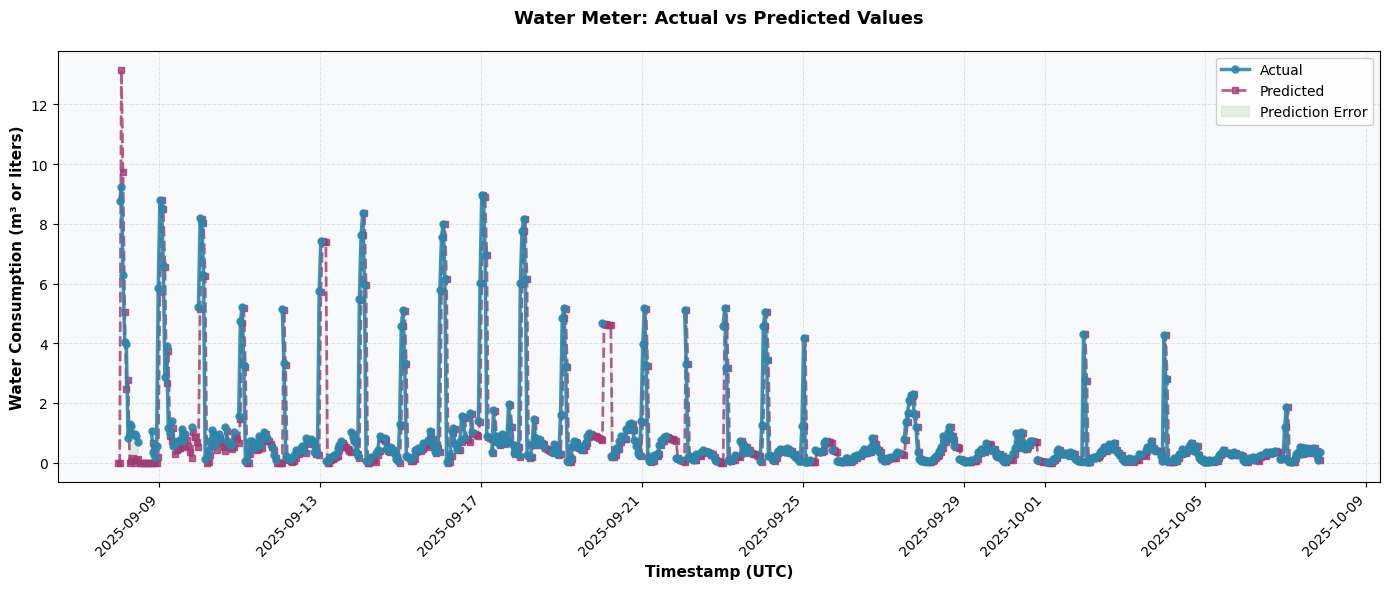

In [19]:
from local_level_fixed_slope import process_single_meter
process_single_meter(f'../data_w_diff_001/{meter_id}.csv', predictions_output_csv='../test_pred.csv')
df = pd.read_csv('../test_pred.csv')
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

fig1, ax1 = plot_water_meter_anomalies(df)
plt.show()

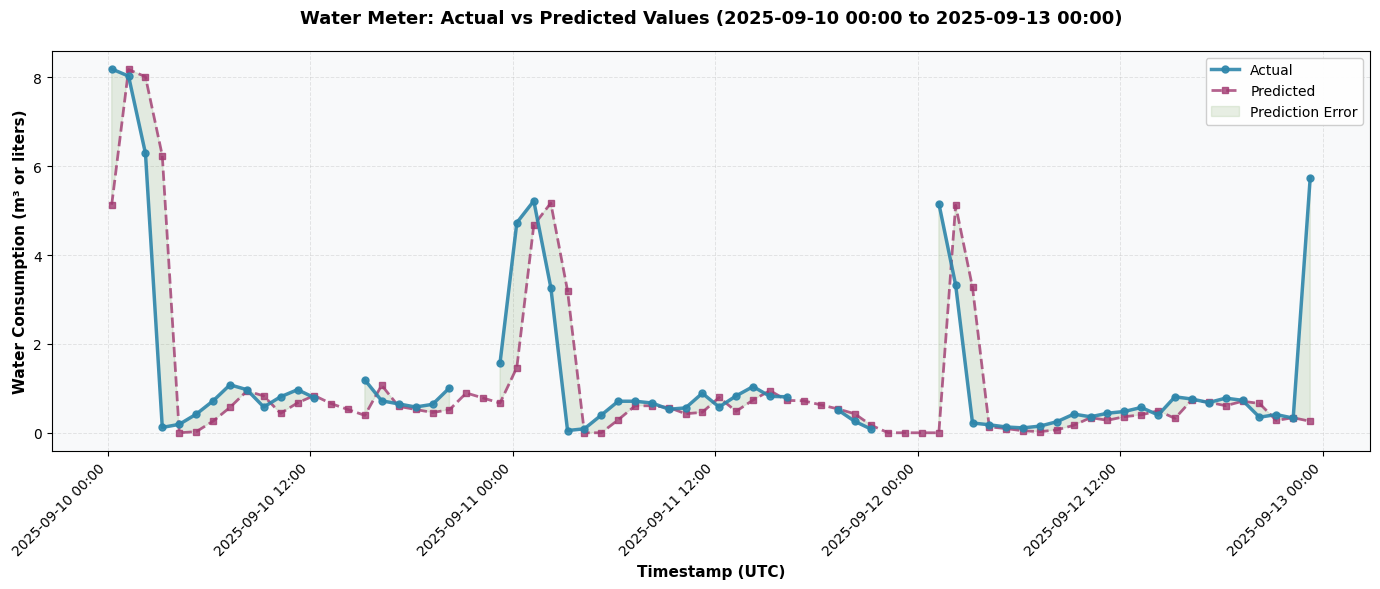

In [20]:
fig2, ax2 = plot_water_meter_anomalies(df, 
        start_date='2025-09-10 00:00:00+00:00',
        end_date='2025-09-13 00:00:00+00:00')
plt.show()

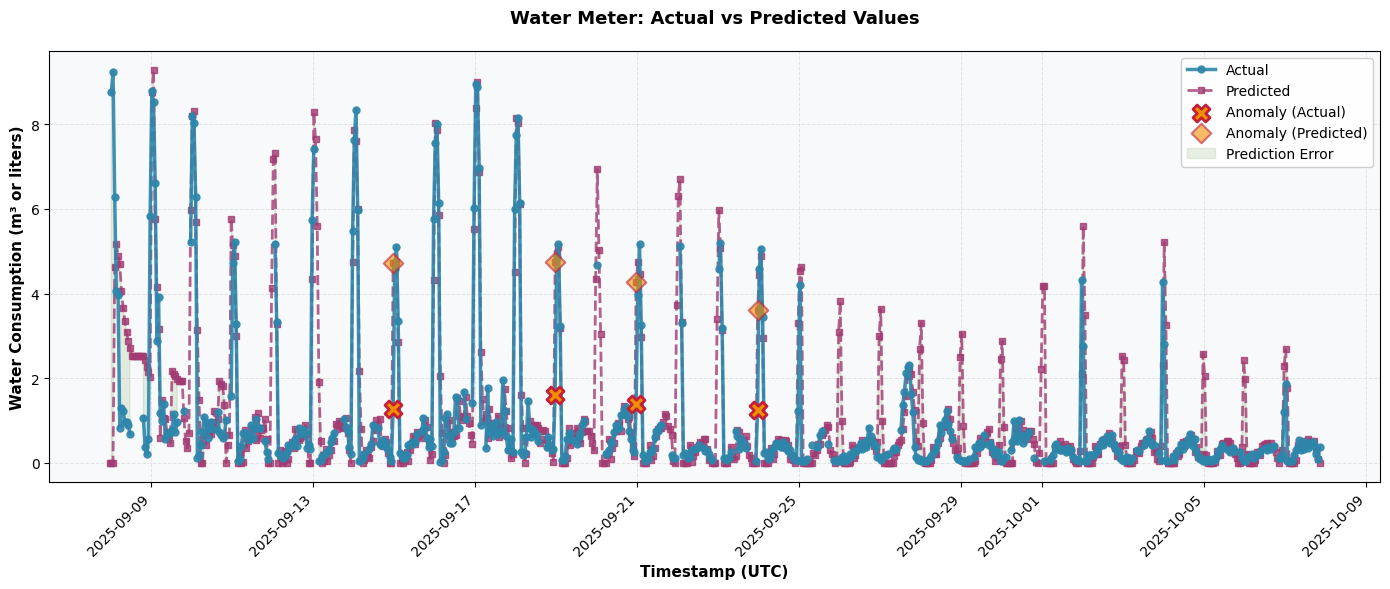

In [21]:
from local_level_unobserved_components import process_single_meter
process_single_meter(f'../data_w_diff_001/{meter_id}.csv', predictions_output_csv='../test_pred_seasonal.csv')
df = pd.read_csv('../test_pred_seasonal.csv')
df['timestamp_utc'] = pd.to_datetime(df['timestamp_utc'])

fig1, ax1 = plot_water_meter_anomalies(df)
plt.show()

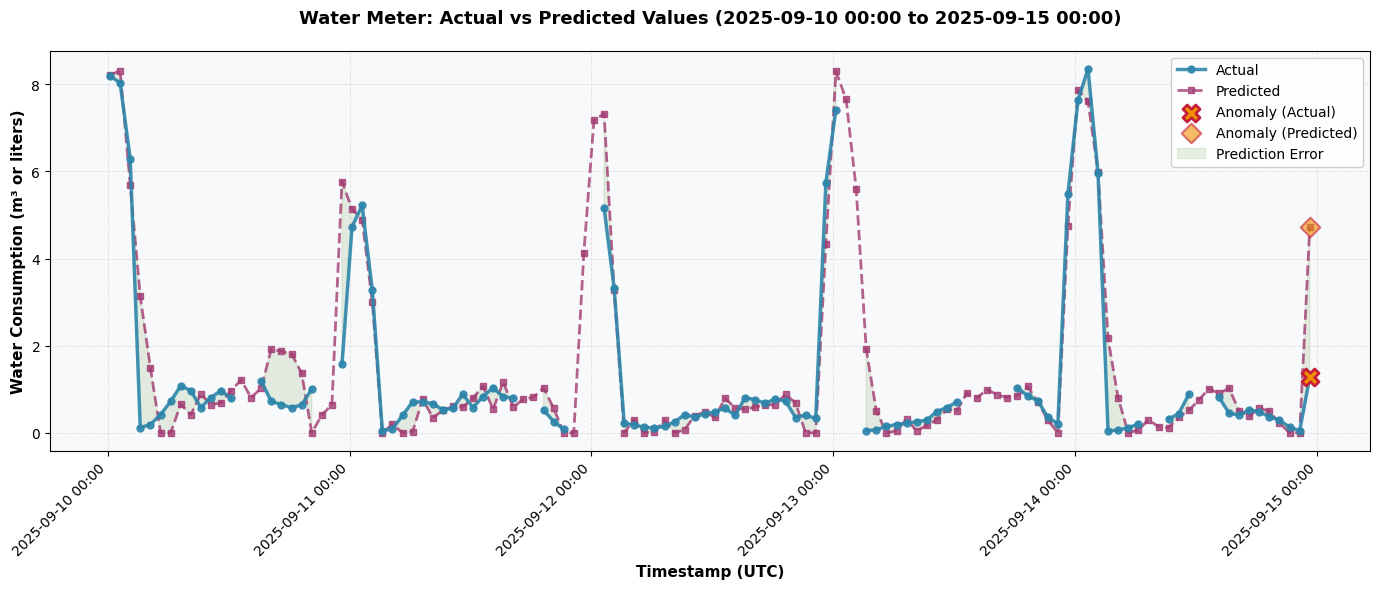

In [22]:
fig2, ax2 = plot_water_meter_anomalies(df, 
        start_date='2025-09-10 00:00:00+00:00',
        end_date='2025-09-15 00:00:00+00:00')
plt.show()

In [23]:
from typing import List


def plot_metric_histogram(summary_df: pd.DataFrame,
                         metric_name: str,
                         model_names: List[str] = None,
                         figsize: tuple = (15, 5),
                         bins: int = 20,
                         alpha: float = 0.7) -> None:
    """
    Create side-by-side histograms for a metric across all models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary() - contains raw metric data
    metric_name : str
        Name of metric to visualize (e.g., 'metric_mae_nz')
    model_names : List[str], optional
        Model names (auto-detected if not provided)
    figsize : tuple
        Figure size (width, height) in inches
    bins : int
        Number of bins for histograms
    alpha : float
        Transparency of bars (0-1)

    Examples
    --------
    >>> plot_metric_histogram(summary_df, 'metric_mae_nz', bins=20)
    >>> plot_metric_histogram(summary_df, 'metric_rmse_nz', 
    ...                       model_names=['LSTM', 'GRU', 'Transformer'])
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Get the raw data for this metric
    metric_row = summary_df[summary_df['Metric'] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        return None

    # Create figure with subplots
    n_models = len(model_names)
    fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)

    # Handle single model case
    if n_models == 1:
        axes = [axes]

    # Extract mean and std for each model
    colors = plt.cm.Set3(np.linspace(0, 1, n_models))

    for idx, (model_name, ax) in enumerate(zip(model_names, axes)):
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if np.isnan(mean_val):
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=14)
            ax.set_title(f'{model_name}\n(No data)', fontsize=12, fontweight='bold')
            continue

        # Create histogram data from mean and std
        # Simulate distribution: generate samples from normal distribution
        data = np.random.normal(mean_val, std_val, 1000)

        ax.hist(data, bins=bins, alpha=alpha, color=colors[idx], edgecolor='black', linewidth=1.2)

        # Add mean and std lines
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
        ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, label=f'±Std: {std_val:.4f}')
        ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)

        ax.set_title(f'{model_name}\nμ={mean_val:.4f}, σ={std_val:.4f}', 
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Value', fontsize=10)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('Frequency', fontsize=10)

    fig.suptitle(f'Distribution of {metric_name} Across Models', 
                fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()


def plot_all_metric_histograms(summary_df: pd.DataFrame,
                              model_names: List[str] = None,
                              metrics_to_plot: List[str] = None,
                              figsize: tuple = (15, 10),
                              bins: int = 20) -> None:
    """
    Create a grid of histograms for multiple metrics across all models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names
    metrics_to_plot : List[str], optional
        Specific metrics to plot. If None, plots non-zero metrics.
    figsize : tuple
        Figure size for the grid
    bins : int
        Number of bins for histograms

    Examples
    --------
    >>> plot_all_metric_histograms(summary_df)
    >>> plot_all_metric_histograms(summary_df, 
    ...                            metrics_to_plot=['metric_mae_nz', 'metric_rmse_nz', 'metric_r2_nz'])
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Get metrics to plot
    if metrics_to_plot is None:
        # Default: plot non-zero metrics only
        all_metrics = summary_df['Metric'].unique()
        metrics_to_plot = [m for m in all_metrics if '_nz' in m or 'non_zero' in m or 'total_count' in m]

    # Create grid
    n_metrics = len(metrics_to_plot)
    n_cols = 3
    n_rows = (n_metrics + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten for easier indexing

    colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))

    for idx, metric_name in enumerate(metrics_to_plot):
        ax = axes[idx]

        metric_row = summary_df[summary_df['Metric'] == metric_name]

        if len(metric_row) == 0:
            ax.text(0.5, 0.5, f'{metric_name}\nNot Found', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(metric_name, fontsize=10, fontweight='bold')
            continue

        # Plot histogram for each model
        has_data = False
        for model_idx, model_name in enumerate(model_names):
            mean_val = metric_row[f"{model_name}_Mean"].values[0]
            std_val = metric_row[f"{model_name}_Std"].values[0]

            if np.isnan(mean_val):
                continue

            has_data = True
            data = np.random.normal(mean_val, std_val, 500)
            ax.hist(data, bins=bins, alpha=0.6, color=colors[model_idx], 
                   label=model_name, edgecolor='black', linewidth=0.5)

        if not has_data:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                   transform=ax.transAxes)

        ax.set_title(metric_name, fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(metrics_to_plot), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Metric Distributions Across Models', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_metric_comparison_violin(summary_df: pd.DataFrame,
                                 metric_name: str,
                                 model_names: List[str] = None,
                                 figsize: tuple = (12, 6)) -> None:
    """
    Create violin plots for comparing metric distributions across models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    metric_name : str
        Metric to visualize
    model_names : List[str], optional
        Model names
    figsize : tuple
        Figure size

    Examples
    --------
    >>> plot_metric_comparison_violin(summary_df, 'metric_mae_nz')
    """

    try:
        import seaborn as sns
    except ImportError:
        print("⚠ seaborn not installed. Install with: pip install seaborn")
        return

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    metric_row = summary_df[summary_df['Metric'] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        return

    # Prepare data for violin plot
    data_list = []
    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if np.isnan(mean_val):
            continue

        # Generate samples from distribution
        samples = np.random.normal(mean_val, std_val, 200)
        for sample in samples:
            data_list.append({'Model': model_name, 'Value': sample})

    data = pd.DataFrame(data_list)

    fig, ax = plt.subplots(figsize=figsize)

    sns.violinplot(data=data, x='Model', y='Value', ax=ax, palette='Set2')

    ax.set_title(f'Distribution of {metric_name} Across Models', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# ============================================================================
# QUICK USAGE EXAMPLES
# ============================================================================
"""
Usage in Jupyter Notebook:

# 1. Simple histogram for one metric
plot_metric_histogram(summary_df, 'metric_mae_nz')

# 2. Specify number of bins and model names
plot_metric_histogram(summary_df, 'metric_rmse_nz', 
                     model_names=['LSTM', 'GRU', 'Transformer'],
                     bins=30, figsize=(18, 5))

# 3. Plot multiple metrics in a grid
plot_all_metric_histograms(summary_df)

# 4. Plot specific metrics
plot_all_metric_histograms(summary_df, 
                          metrics_to_plot=['metric_mae_nz', 'metric_rmse_nz', 
                                          'metric_r2_nz', 'metric_mape_nz'])

# 5. Violin plots (requires seaborn)
plot_metric_comparison_violin(summary_df, 'metric_mae_nz')
"""


"\nUsage in Jupyter Notebook:\n\n# 1. Simple histogram for one metric\nplot_metric_histogram(summary_df, 'metric_mae_nz')\n\n# 2. Specify number of bins and model names\nplot_metric_histogram(summary_df, 'metric_rmse_nz', \n                     model_names=['LSTM', 'GRU', 'Transformer'],\n                     bins=30, figsize=(18, 5))\n\n# 3. Plot multiple metrics in a grid\nplot_all_metric_histograms(summary_df)\n\n# 4. Plot specific metrics\nplot_all_metric_histograms(summary_df, \n                          metrics_to_plot=['metric_mae_nz', 'metric_rmse_nz', \n                                          'metric_r2_nz', 'metric_mape_nz'])\n\n# 5. Violin plots (requires seaborn)\nplot_metric_comparison_violin(summary_df, 'metric_mae_nz')\n"

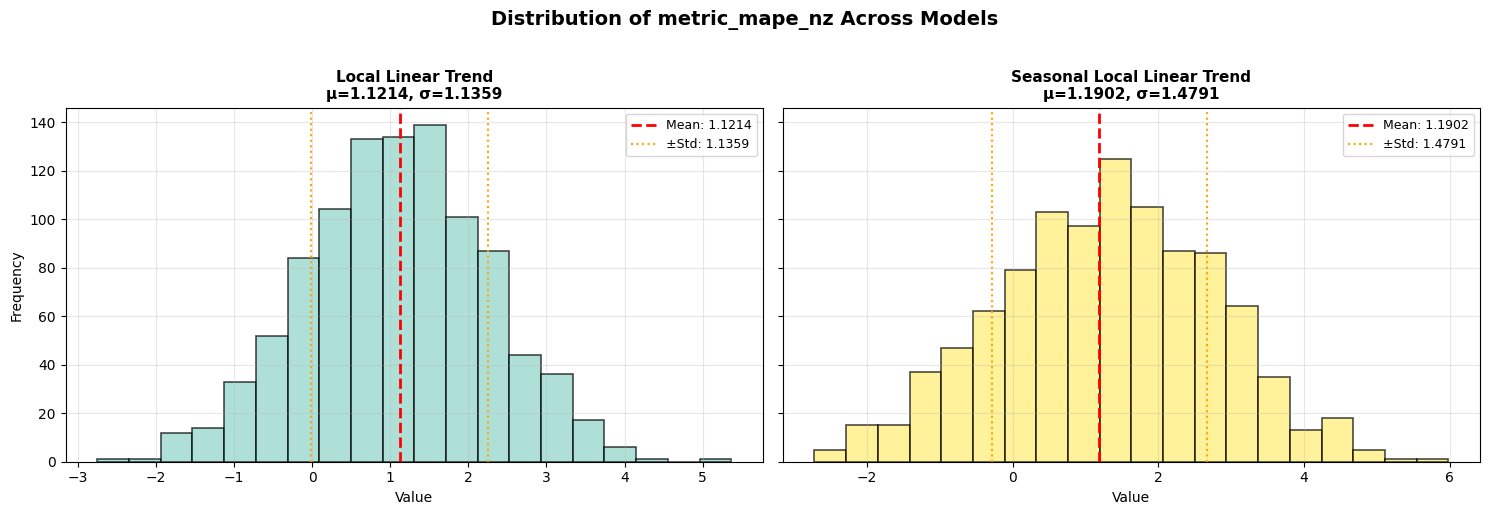

In [24]:
plot_metric_histogram(summary_converged_only, 'metric_mape_nz')

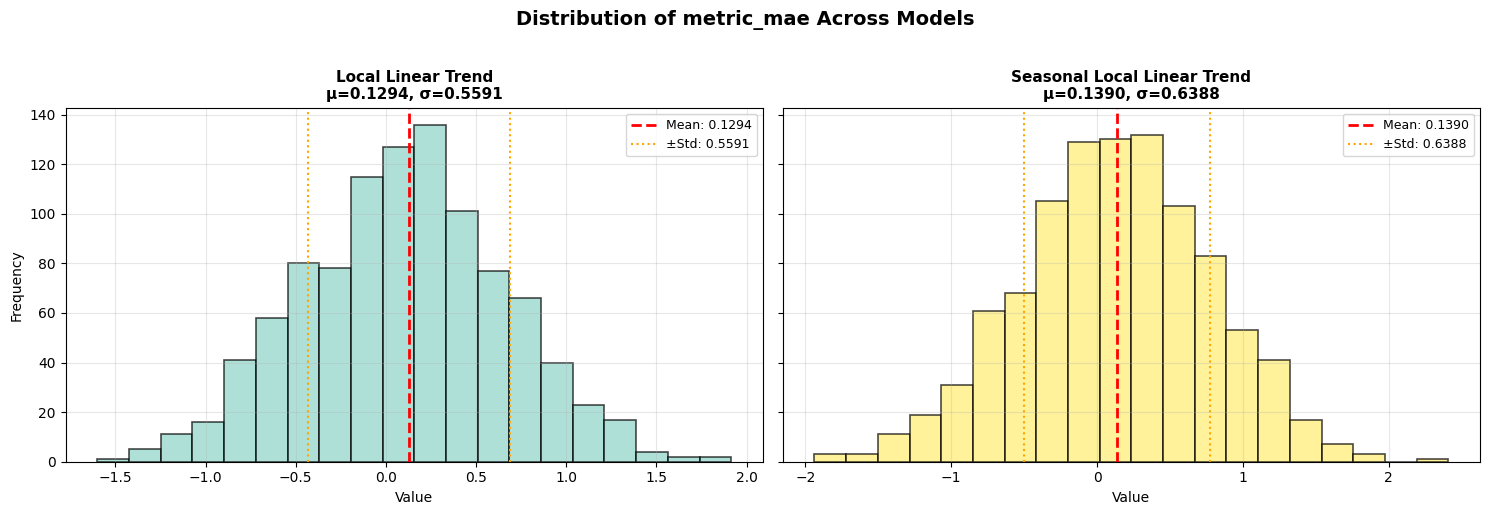

In [25]:
plot_metric_histogram(summary_converged_only, 'metric_mae')

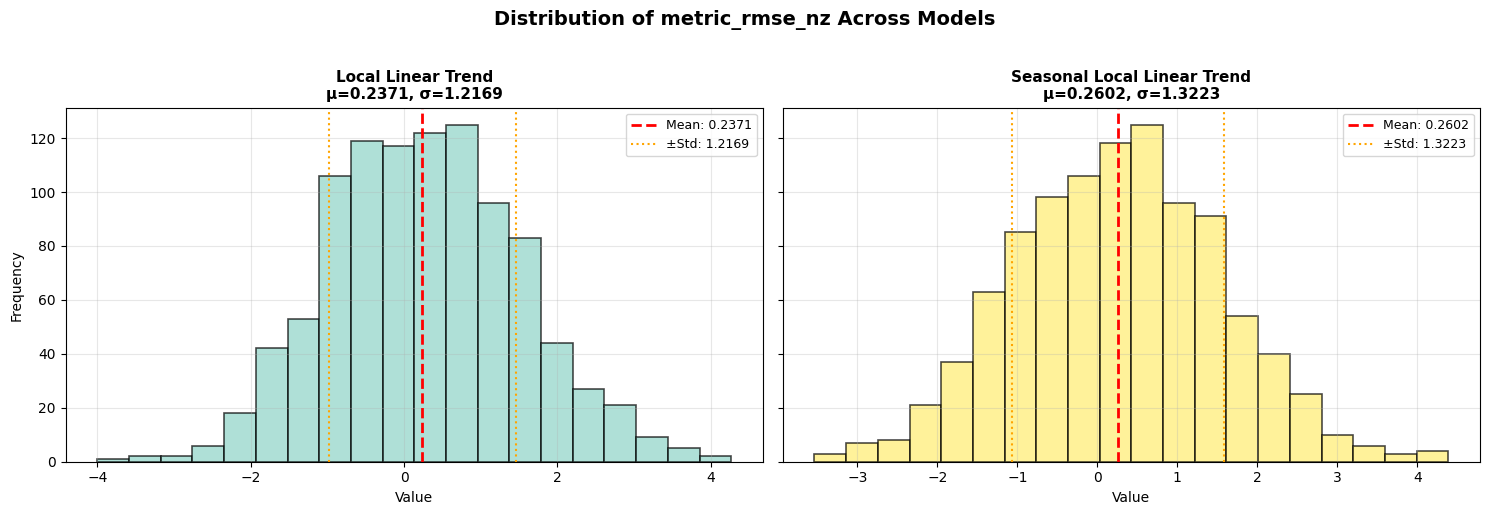

In [27]:
plot_metric_histogram(summary_converged_only, 'metric_rmse_nz')